# 02 · Fine-Tune the Detector — v1 & v2 🍽️

**Lab Phases 4, 5 & the Final Experiment.**

Fine-tunes a pretrained **YOLO11** model on Bahraini-food dataset, evaluates it,
then compares **v1** (first round) against **v2** (after targeted data collection).

> ⚡ **Use a GPU.** CPU training works but is slow. Free option: open this notebook in
> **Google Colab** → *Runtime → Change runtime type → GPU*.

In [1]:
# Install (uncomment on a fresh machine / Colab):
!pip install -q ultralytics roboflow

In [2]:
import os, sys, shutil
from pathlib import Path
cwd = os.getcwd()
ROOT = os.path.abspath(os.path.join(cwd, "..")) if os.path.basename(cwd).lower() == "notebooks" else cwd
sys.path.insert(0, os.path.join(ROOT, "src"))
import utils as U
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MODELS_DIR = Path(ROOT) / "models"; RESULTS_DIR = Path(ROOT) / "results"; RUNS_DIR = Path(ROOT) / "runs"
MODELS_DIR.mkdir(exist_ok=True); RESULTS_DIR.mkdir(exist_ok=True)

import torch
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| device:", DEVICE)
if DEVICE == "cpu":
    print("NOTE: no GPU detected -> training will be slow. Consider Google Colab (free GPU).")

torch 2.13.0+cpu | CUDA: False | device: cpu
NOTE: no GPU detected -> training will be slow. Consider Google Colab (free GPU).


## 1 · Get the labeled dataset
Choose **ONE**: **A)** download straight from Roboflow (recommended — reproducible), or
**B)** point to a folder you already exported into `./datasets`.

In [3]:
from ultralytics import YOLO
import yaml

# ---- OPTION A: Roboflow API (fill these in) -----------------------------
ROBOFLOW_API_KEY = ""          # roboflow.com -> account -> Settings -> API key (Private)
WORKSPACE        = ""          # your workspace id  (from the project URL)
PROJECT          = ""          # your project id    (from the project URL)
VERSION          = 1           # dataset version number
EXPORT_FORMAT    = "yolov11"   # "yolov8" also works (same label format)

# ---- OPTION B: local export folder (used only if API key is empty) ------
LOCAL_DATASET_DIR = None       # e.g. os.path.join(ROOT, "datasets", "bahraini-food")

def get_data_yaml(version, local_dir):
    if ROBOFLOW_API_KEY:
        from roboflow import Roboflow
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        v = rf.workspace(WORKSPACE).project(PROJECT).version(version)
        loc = str(Path(ROOT) / "datasets" / f"{PROJECT}-v{version}")
        ds = v.download(EXPORT_FORMAT, location=loc)
        return os.path.join(ds.location, "data.yaml")
    found = U.find_data_yaml(local_dir or str(Path(ROOT) / "datasets"))
    assert found, "No dataset found. Set the Roboflow keys, or export into ./datasets."
    return found

DATA_YAML = get_data_yaml(VERSION, LOCAL_DATASET_DIR)
print("data.yaml:", DATA_YAML)

Creating new Ultralytics Settings v0.0.7 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Barho\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
data.yaml: C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW1\data.yaml


In [4]:
# Rewrite train/val/test to ABSOLUTE paths so YOLO always finds them (Windows-safe).
def absolutize(data_yaml):
    resolved = U.load_data_yaml(data_yaml)
    with open(data_yaml, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    raw["path"]  = resolved["root"]
    raw["train"] = resolved["splits"]["train"]
    raw["val"]   = resolved["splits"]["val"]
    raw["test"]  = resolved["splits"]["test"]
    raw["names"] = resolved["names"]; raw["nc"] = resolved["nc"]
    with open(data_yaml, "w", encoding="utf-8") as f:
        yaml.safe_dump(raw, f, sort_keys=False, allow_unicode=True)
    return resolved

data = absolutize(DATA_YAML)
print("Classes:", data["names"])

Classes: ['Balaleet', 'Fried Fish', 'Halwa', 'Harees', 'Kebab', 'Luqaimat', 'Machboos', 'Mattai', 'Nakhi', 'Samboosa']


## 2 · Baseline — the pretrained model *before* fine-tuning
Stock YOLO11 is trained on **COCO** (people, cars, cups…), **not** Bahraini food.
Running it now shows *why* fine-tuning is needed: it finds nothing, or mislabels dishes
as generic COCO things (`bowl`, `cake`, `donut`…).

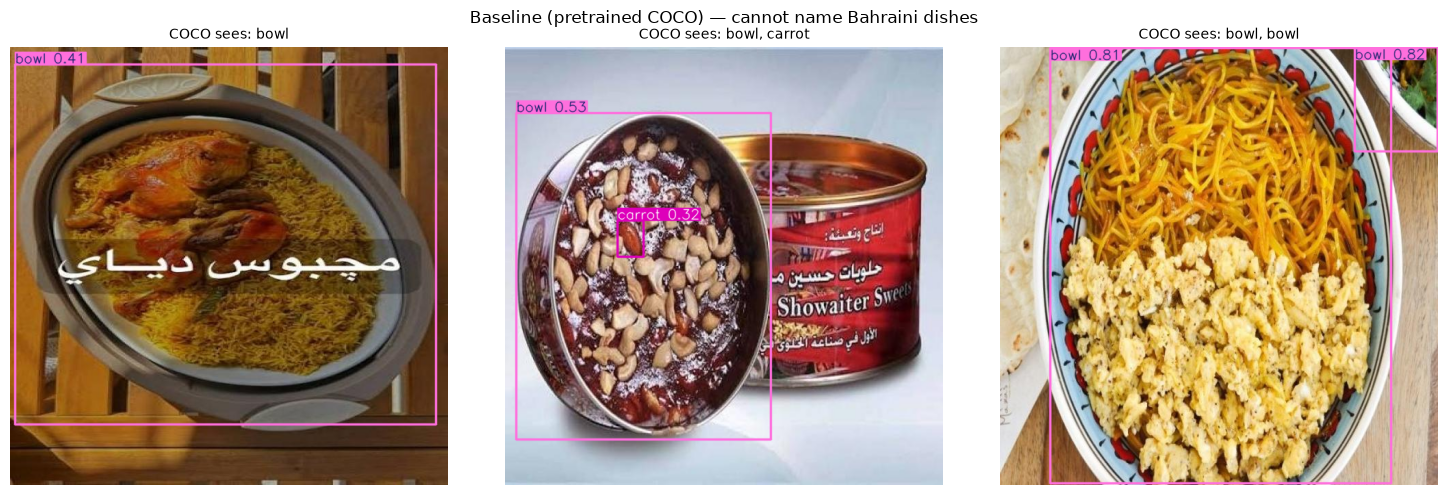

In [5]:
import random
base = YOLO("yolo11s.pt")   # COCO-pretrained weights (auto-downloads)
train_imgs = U.list_images(data["splits"]["train"]); random.seed(0)
demo = random.sample(train_imgs, min(3, len(train_imgs)))
res = base.predict(demo, conf=0.25, verbose=False)
fig, axes = plt.subplots(1, len(res), figsize=(5 * len(res), 5))
axes = np.atleast_1d(axes)
for ax, r in zip(axes, res):
    ax.imshow(r.plot()[:, :, ::-1]); ax.axis("off")
    found = [base.names[int(c)] for c in r.boxes.cls] if r.boxes is not None else []
    ax.set_title("COCO sees: " + (", ".join(found) if found else "nothing"), fontsize=10)
plt.suptitle("Baseline (pretrained COCO) — cannot name Bahraini dishes"); plt.tight_layout(); plt.show()

## 3 · Fine-tune v1
Tune the knobs and train. YOLO applies its built-in augmentation (mosaic, flips, HSV,
scale) to the **training images only** — so "augment only the training set" is handled
for you. Lower `BATCH` if you hit a GPU out-of-memory error.

In [7]:
BASE_MODEL = "yolo11s.pt"   # yolo11n.pt = fastest, yolo11m.pt = more accurate
EPOCHS     = 2
IMGSZ      = 640
BATCH      = 16             # try 8 or 4 if GPU memory is tight; -1 = auto
PATIENCE   = 20            # early-stop if validation mAP stops improving

model = YOLO(BASE_MODEL)
model.train(data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, patience=PATIENCE,
            device=DEVICE, seed=0, project=str(RUNS_DIR), name="finetune_v1",
            exist_ok=True, plots=True)

shutil.copy(RUNS_DIR / "finetune_v1" / "weights" / "best.pt", MODELS_DIR / "best_v1.pt")
print("Saved:", MODELS_DIR / "best_v1.pt")

Ultralytics 8.4.118  Python-3.13.12 torch-2.13.0+cpu CPU (Intel Core i7-9750HF 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW1\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentu

## 4 · Evaluate v1 on the unseen test set
Precision, Recall, mAP50 and mAP50-95 — overall and per class.

In [8]:
metrics_v1 = model.val(data=DATA_YAML, split="test", device=DEVICE,
                       project=str(RUNS_DIR), name="eval_v1", exist_ok=True, plots=True)
overall_v1, per_class_v1 = U.summarize_metrics(metrics_v1)
print("v1 OVERALL:", {k: round(v, 3) for k, v in overall_v1.items()})
per_class_v1.to_csv(RESULTS_DIR / "per_class_v1.csv", index=False)
per_class_v1

Ultralytics 8.4.118  Python-3.13.12 torch-2.13.0+cpu CPU (Intel Core i7-9750HF 2.60GHz)
YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 74.99.9 MB/s, size: 64.6 KB)
val: Scanning C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW1\test\labels... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 1.2Kit/s 0.0s
val: New cache created: C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\datasets\ROBOFLOW1\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.0s/it 8.0s<21.5s
                   all         19         24      0.615      0.425      0.451      0.281
                 Halwa          5          5      0.473        0.4      0.335      0.222
                Harees          1          1          1          0      0.199      0.159
                 Kebab     

,class,precision,recall,mAP50,mAP50-95
0,Harees,1.000000,0.000000,0.199000,0.159200
1,Kebab,0.492152,0.486266,0.435602,0.194674
2,Halwa,0.472962,0.400000,0.335230,0.222393
3,Nakhi,0.254532,0.666667,0.613235,0.383824
4,Mattai,0.853300,0.571429,0.671656,0.445950


## 5 · ⏸ Stop here and do the Error Analysis
Open **`03_testing_and_deployment.ipynb`**, run the error analysis, and use it to plan
**round-2 targeted collection** (Lab Phase 7). Label those new images in Roboflow as a
**new version**, then come back and run the rest of this notebook.

## 6 · Fine-tune v2 (after adding targeted data)
Set the config to your **round-2** Roboflow version (v1 images **+** the new targeted
images). Keep the **same** hyperparameters so the comparison is fair.

In [ ]:
VERSION_V2       = 2          # your round-2 Roboflow version
LOCAL_DATASET_V2 = None       # or a local export folder

DATA_YAML_V2 = get_data_yaml(VERSION_V2, LOCAL_DATASET_V2)
absolutize(DATA_YAML_V2)
print("data.yaml (v2):", DATA_YAML_V2)

model_v2 = YOLO(BASE_MODEL)
model_v2.train(data=DATA_YAML_V2, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, patience=PATIENCE,
               device=DEVICE, seed=0, project=str(RUNS_DIR), name="finetune_v2",
               exist_ok=True, plots=True)
shutil.copy(RUNS_DIR / "finetune_v2" / "weights" / "best.pt", MODELS_DIR / "best_v2.pt")
print("Saved:", MODELS_DIR / "best_v2.pt")

## 7 · Final Experiment — did v2 actually improve?
Evaluate v2 on the test set and compare against v1.

In [ ]:
metrics_v2 = model_v2.val(data=DATA_YAML_V2, split="test", device=DEVICE,
                          project=str(RUNS_DIR), name="eval_v2", exist_ok=True, plots=True)
overall_v2, per_class_v2 = U.summarize_metrics(metrics_v2)

cmp = pd.DataFrame({"Fine-tuned v1": overall_v1, "Fine-tuned v2": overall_v2}).T
display(cmp.round(3))
cmp.round(4).to_csv(RESULTS_DIR / "comparison_v1_v2.csv")

mets = ["precision", "recall", "mAP50", "mAP50-95"]
x = np.arange(len(mets)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, [overall_v1[m] for m in mets], w, label="v1", color="#4c78a8")
ax.bar(x + w/2, [overall_v2[m] for m in mets], w, label="v2", color="#54a24b")
ax.set_xticks(x); ax.set_xticklabels(mets); ax.set_ylim(0, 1); ax.legend()
ax.set_title("Fine-tuned v1 vs v2")
for i, m in enumerate(mets):
    ax.text(i - w/2, overall_v1[m], f"{overall_v1[m]:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, overall_v2[m], f"{overall_v2[m]:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "comparison_v1_v2.png", dpi=130); plt.show()

## 8 · Tips — experiment tracking & retraining
- Every run is saved under `runs/finetune_*/` with weights, curves and a `results.csv`.
- **Change a hyperparameter and re-run** to experiment — give it a new `name=` to keep runs separate.
- Resume an interrupted run: `YOLO("runs/finetune_v1/weights/last.pt").train(resume=True)`.
- More accuracy: bigger model (`yolo11m.pt`), more `EPOCHS`, or more/better data.
- The chosen weights live in `models/best_v1.pt` and `models/best_v2.pt` for the app & test notebook.